--- Federated Learning (UC Merced) - Final Efficient Mode ---
Running on: cuda
Data loaded: 1680 Train / 420 Test images.

Model Size: 49.41 MB (Down) | 49.41 MB (Up)

--- Round 1/25 (LR: 0.001500) ---
  > Client 0: Starting local training...
    > Client 0 Epoch 1/6 Summary: Avg Loss: 3.1406, Train Acc: 0.0441
    > Client 0 Epoch 2/6 Summary: Avg Loss: 2.9686, Train Acc: 0.0752
    > Client 0 Epoch 3/6 Summary: Avg Loss: 2.8583, Train Acc: 0.1277
    > Client 0 Epoch 4/6 Summary: Avg Loss: 2.5525, Train Acc: 0.2014
    > Client 0 Epoch 5/6 Summary: Avg Loss: 2.4204, Train Acc: 0.2011
    > Client 0 Epoch 6/6 Summary: Avg Loss: 2.2091, Train Acc: 0.2594
  > Client 0: Local training complete.
  > Client 1: Starting local training...
    > Client 1 Epoch 1/6 Summary: Avg Loss: 3.1863, Train Acc: 0.0442
    > Client 1 Epoch 2/6 Summary: Avg Loss: 3.0391, Train Acc: 0.0341
    > Client 1 Epoch 3/6 Summary: Avg Loss: 3.0217, Train Acc: 0.0581
    > Client 1 Epoch 4/6 Summary: Avg Loss: 2.9

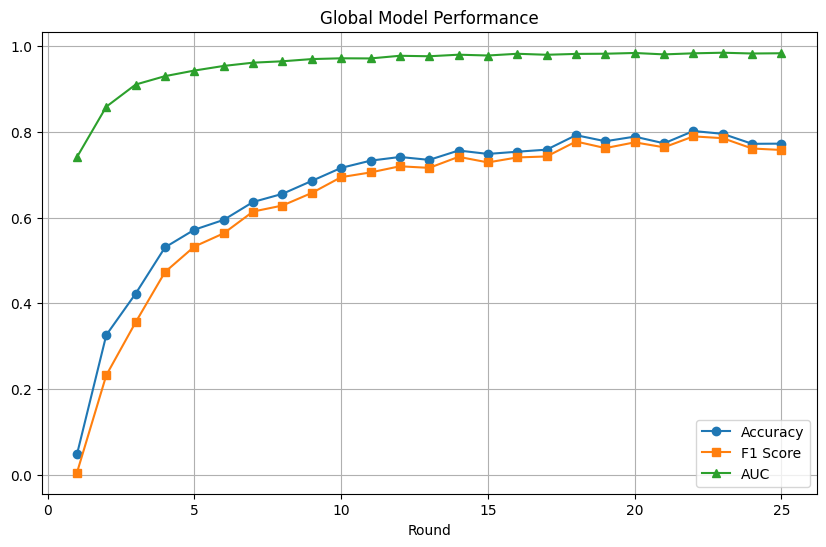

Evaluating final client accuracy...


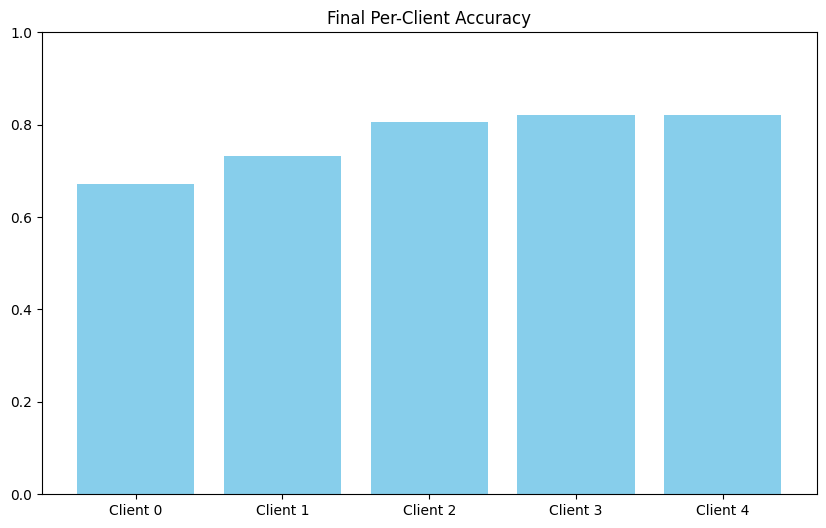

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import copy
import math
import sys
import time

# --- 1. CONFIGURATION ---

# !! IMPORTANT !! UPDATE THIS PATH
DATA_PATH = r'C:\Users\hp\Downloads\archive (2)\UCMerced_LandUse\Images' 

# --- CHANGE: Unique Checkpoint Name ---
CHECKPOINT_PATH = './fl_checkpoint_ucmerced_final.pth'

# --- EFFICIENT HYPERPARAMETERS ---
NUM_CLIENTS = 5         
NUM_ROUNDS = 25         
LOCAL_EPOCHS = 6        
BATCH_SIZE = 32         
LEARNING_RATE = 0.0015  
CLIENT_TEST_SPLIT = 0.2 
NUM_CLASSES = 21        

# --- System Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# --- 2. MODEL DEFINITION ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(), nn.MaxPool2d(2, 2)) 
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(), nn.MaxPool2d(2, 2)) 
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(), nn.MaxPool2d(2, 2)) 
        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(), nn.MaxPool2d(2, 2)) 
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.flatten(x)
        logits = self.fc(x)
        return logits

# --- 3. DATA PREPARATION ---
def get_dataloaders(data_path, num_clients):
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Data path not found: {data_path}")

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    full_dataset = ImageFolder(root=data_path, transform=train_transform)
    total_size = len(full_dataset)
    train_size = int(0.8 * total_size)
    test_size = total_size - train_size
    train_dataset, global_test_dataset = random_split(full_dataset, [train_size, test_size])
    
    global_test_loader = DataLoader(global_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    train_indices = np.array(train_dataset.indices)
    np.random.shuffle(train_indices)
    client_split_indices = np.array_split(train_indices, num_clients)
    
    client_loaders = []
    client_data_sizes = []
    
    for i in range(num_clients):
        client_idx = client_split_indices[i]
        local_test_len = int(len(client_idx) * CLIENT_TEST_SPLIT)
        local_train_len = len(client_idx) - local_test_len
        local_train_idx = client_idx[:local_train_len]
        local_test_idx = client_idx[local_train_len:]
        local_train_subset = Subset(full_dataset, local_train_idx)
        local_test_subset = Subset(full_dataset, local_test_idx)
        train_loader = DataLoader(local_train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        test_loader = DataLoader(local_test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        client_loaders.append((train_loader, test_loader))
        client_data_sizes.append(local_train_len)
        
    print(f"Data loaded: {train_size} Train / {test_size} Test images.")
    return global_test_loader, client_loaders, client_data_sizes

# --- 4. HELPER FUNCTIONS ---
def get_model_bytes(model, only_trainable=False):
    total_bytes = 0
    for param in model.parameters():
        if only_trainable and not param.requires_grad:
            continue
        total_bytes += param.numel() * param.element_size()
    return total_bytes

def evaluate_global(model, test_loader, device, metrics_dict):
    model.eval()
    for metric in metrics_dict.values():
        metric.reset()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            metrics_dict['acc'].update(outputs, labels)
            metrics_dict['f1'].update(outputs, labels)
            probs = F.softmax(outputs, dim=1)
            metrics_dict['auc'].update(probs, labels)
    return {
        'acc': metrics_dict['acc'].compute().item(),
        'f1': metrics_dict['f1'].compute().item(),
        'auc': metrics_dict['auc'].compute().item(),
    }

# --- 5. CLIENT CLASS ---
class Client:
    def __init__(self, client_id, model_template, train_loader, test_loader, device, lr=0.001):
        self.client_id = client_id
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.device = device
        self.model = copy.deepcopy(model_template).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.criterion = nn.CrossEntropyLoss()
        # Metric for local training logs
        self.train_acc_metric = torchmetrics.classification.MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)

    def set_parameters(self, global_state_dict):
        self.model.load_state_dict(global_state_dict)

    def train(self, local_epochs):
        self.model.train()
        # --- CHANGE: RESTORED PRINT STATEMENT ---
        print(f"  > Client {self.client_id}: Starting local training...")
        
        for epoch in range(local_epochs):
            self.train_acc_metric.reset()
            total_epoch_loss = 0.0
            num_batches = 0
            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                total_epoch_loss += loss.item()
                self.train_acc_metric.update(outputs, labels)
                num_batches += 1
            
            # --- CHANGE: RESTORED EPOCH SUMMARY PRINT ---
            if num_batches > 0:
                avg_loss = total_epoch_loss / num_batches
                train_acc = self.train_acc_metric.compute().item()
                print(f"    > Client {self.client_id} Epoch {epoch+1}/{local_epochs} Summary: Avg Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}")

        # --- CHANGE: RESTORED COMPLETION PRINT ---
        print(f"  > Client {self.client_id}: Local training complete.")

    def get_parameters(self):
        return self.model.state_dict()

    def evaluate(self):
        self.model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        return correct / total if total > 0 else 0

# --- 6. FEDAVG ---
def fed_avg(client_weights_list, client_data_sizes):
    total_data_size = sum(client_data_sizes)
    weights = [size / total_data_size for size in client_data_sizes]
    avg_state_dict = copy.deepcopy(client_weights_list[0])
    for key in avg_state_dict.keys():
        avg_state_dict[key] = torch.zeros_like(avg_state_dict[key])
    for key in avg_state_dict.keys():
        for i, state_dict in enumerate(client_weights_list):
            avg_state_dict[key] += state_dict[key] * weights[i]
    return avg_state_dict

# --- 7. MAIN SIMULATION ---
def main():
    print(f"--- Federated Learning (UC Merced) - Final Efficient Mode ---")
    print(f"Running on: {DEVICE}")
    
    # Data Load
    global_test_loader, client_loaders, client_data_sizes = get_dataloaders(DATA_PATH, NUM_CLIENTS)

    # Model & Checkpoint Setup
    model_template = SimpleCNN(num_classes=NUM_CLASSES)
    global_model = copy.deepcopy(model_template).to(DEVICE)
    
    start_round = 0
    global_acc_log = []
    global_f1_log = []
    global_auc_log = []
    cumulative_comm_log = []

    if os.path.exists(CHECKPOINT_PATH):
        print(f"Loading checkpoint: {CHECKPOINT_PATH}")
        try:
            ckpt = torch.load(CHECKPOINT_PATH)
            start_round = ckpt['round']
            global_model.load_state_dict(ckpt['model_state_dict'])
            global_acc_log = ckpt['global_acc_log']
            global_f1_log = ckpt['global_f1_log']
            global_auc_log = ckpt['global_auc_log']
            cumulative_comm_log = ckpt.get('cumulative_comm_log', [])
            print(f"Resuming from Round {start_round + 1}")
        except:
            print("Checkpoint mismatch. Starting fresh.")
            start_round = 0
    
    # Metrics
    global_metrics_dict = {
        'acc': torchmetrics.classification.MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE),
        'f1': torchmetrics.classification.MulticlassF1Score(num_classes=NUM_CLASSES, average='macro').to(DEVICE),
        'auc': torchmetrics.classification.MulticlassAUROC(num_classes=NUM_CLASSES, average='macro', thresholds=None).to(DEVICE)
    }
    
    bytes_down = get_model_bytes(global_model, only_trainable=False)
    bytes_up = get_model_bytes(global_model, only_trainable=True)
    total_comm_bytes = cumulative_comm_log[-1] if cumulative_comm_log else 0
    
    print(f"\nModel Size: {bytes_down / (1024**2):.2f} MB (Down) | {bytes_up / (1024**2):.2f} MB (Up)")

    # --- TRAINING LOOP ---
    for round_num in range(start_round, start_round + NUM_ROUNDS):
        
        # Cosine Annealing Scheduler
        progress = round_num / NUM_ROUNDS
        current_lr = 0.5 * LEARNING_RATE * (1 + math.cos(math.pi * progress))
            
        print(f"\n--- Round {round_num + 1}/{start_round + NUM_ROUNDS} (LR: {current_lr:.6f}) ---")
        
        global_state_dict = global_model.state_dict()
        client_weights_list = []
        
        # Client Phase
        for i, (train_loader, test_loader) in enumerate(client_loaders):
            client = Client(i, model_template, train_loader, test_loader, DEVICE, lr=current_lr)
            client.set_parameters(global_state_dict)
            total_comm_bytes += bytes_down
            
            client.train(LOCAL_EPOCHS) 
            
            client_weights_list.append(client.get_parameters())
            total_comm_bytes += bytes_up
        
        cumulative_comm_log.append(total_comm_bytes)

        # Server Phase
        print(f"  Aggregating {NUM_CLIENTS} clients...")
        global_state_dict = fed_avg(client_weights_list, client_data_sizes)
        global_model.load_state_dict(global_state_dict)
        
        print("  Evaluating global model...")
        metrics = evaluate_global(global_model, global_test_loader, DEVICE, global_metrics_dict)
        
        global_acc_log.append(metrics['acc'])
        global_f1_log.append(metrics['f1'])
        global_auc_log.append(metrics['auc'])
        
        print(f"  >> Acc: {metrics['acc']:.4f} | F1: {metrics['f1']:.4f} | AUC: {metrics['auc']:.4f}")
        
        # Save Checkpoint
        torch.save({
            'round': round_num + 1,
            'model_state_dict': global_model.state_dict(),
            'global_acc_log': global_acc_log,
            'global_f1_log': global_f1_log,
            'global_auc_log': global_auc_log,
            'cumulative_comm_log': cumulative_comm_log
        }, CHECKPOINT_PATH)

    # --- FINAL PLOTS ---
    print("\n--- Generating Analysis Graphs ---")
    rounds_axis = range(1, len(global_acc_log) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(rounds_axis, global_acc_log, marker='o', label='Accuracy')
    plt.plot(rounds_axis, global_f1_log, marker='s', label='F1 Score')
    plt.plot(rounds_axis, global_auc_log, marker='^', label='AUC')
    plt.title('Global Model Performance')
    plt.xlabel('Round')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Per-Client Variance
    print("Evaluating final client accuracy...")
    client_final_acc = []
    for i, (train_loader, test_loader) in enumerate(client_loaders):
        client = Client(i, model_template, train_loader, test_loader, DEVICE)
        client.set_parameters(global_model.state_dict())
        client_final_acc.append(client.evaluate())
        
    plt.figure(figsize=(10, 6))
    plt.bar([f'Client {i}' for i in range(NUM_CLIENTS)], client_final_acc, color='skyblue')
    plt.title('Final Per-Client Accuracy')
    plt.ylim(0, 1.0)
    plt.show()

if __name__ == "__main__":
    main()